# ***K-Means Clustering — Customer Segmentation.***

# ***Clone GitHub Repo.***

In [32]:
import os

if os.path.exists("220143_DT_-_K_Means_Clustering"):
    import shutil
    shutil.rmtree("220143_DT_-_K_Means_Clustering")

!git clone https://github.com/rubyat43/220143_DT_-_K_Means_Clustering

print("Repo cloned successfully!")
print("Files available:")
!ls 220143_DT_-_K_Means_Clustering/

Cloning into '220143_DT_-_K_Means_Clustering'...
remote: Enumerating objects: 13, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 13 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (13/13), done.
Resolving deltas: 100% (1/1), done.
Repo cloned successfully!
Files available:
dataset  model	README.md


# ***Import All Libraries.***

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_style("whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


# ***Load Standard Dataset***

In [34]:
url = "https://raw.githubusercontent.com/SteffiPeTaffy/machineLearningAZ/master/Machine%20Learning%20A-Z%20Template%20Folder/Part%204%20-%20Clustering/Section%2025%20-%20Hierarchical%20Clustering/Mall_Customers.csv"

df = pd.read_csv(url)

print("Standard dataset loaded!")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")
print("\nFirst 5 rows:")
df.head()

Standard dataset loaded!
Shape: 200 rows × 5 columns

First 5 rows:


,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# ***Data Exploration.***

# **Basic Info.**

In [35]:
print("COLUMN NAMES & DATA TYPES")
print("\n")
print(df.dtypes)

print("\n" + "*"*55)
print("DATASET SHAPE")
print("\n")
print(f"  Rows    : {df.shape[0]}  → each row = 1 customer")
print(f"  Columns : {df.shape[1]}  → each column = 1 feature")

print("\n" + "*"*55)
print("FULL DATASET INFO")
print("\n")
df.info()

COLUMN NAMES & DATA TYPES


CustomerID                 int64
Genre                     object
Age                        int64
Annual Income (k$)         int64
Spending Score (1-100)     int64
dtype: object

*******************************************************
DATASET SHAPE


  Rows    : 200  → each row = 1 customer
  Columns : 5  → each column = 1 feature

*******************************************************
FULL DATASET INFO


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


# **Missing Values.**

In [36]:
print("MISSING VALUES CHECK")
print("\n")
missing = df.isnull().sum()
print(missing)
print(f"\nTotal missing values: {missing.sum()}")
if missing.sum() == 0:
    print("No missing values! Dataset is perfectly clean.")

MISSING VALUES CHECK


CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Total missing values: 0
No missing values! Dataset is perfectly clean.


# **Statistical Summary.**

In [37]:
print("STATISTICAL SUMMARY")
print("\n")
df.describe().round(2)

STATISTICAL SUMMARY




,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00


# **Detailed Stats.**

In [38]:
cols = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

for col in cols:
    print("\n")
    print(f"{col}")
    print("\n")
    print(f"  Min     : {df[col].min()}")
    print(f"  Max     : {df[col].max()}")
    print(f"  Mean    : {df[col].mean():.2f}")
    print(f"  Median  : {df[col].median()}")
    print(f"  Std Dev : {df[col].std():.2f}")
    print(f"  Unique  : {df[col].nunique()} values")
    print()



Age


  Min     : 18
  Max     : 70
  Mean    : 38.85
  Median  : 36.0
  Std Dev : 13.97
  Unique  : 51 values



Annual Income (k$)


  Min     : 15
  Max     : 137
  Mean    : 60.56
  Median  : 61.5
  Std Dev : 26.26
  Unique  : 64 values



Spending Score (1-100)


  Min     : 1
  Max     : 99
  Mean    : 50.20
  Median  : 50.0
  Std Dev : 25.82
  Unique  : 84 values



# **Gender Distribution.(Pie Chart, Count bar).**

GENDER DISTRIBUTION


Genre
Female    112
Male       88
Name: count, dtype: int64

  Male   : 88 customers (44.0%)
  Female : 112 customers (56.0%)


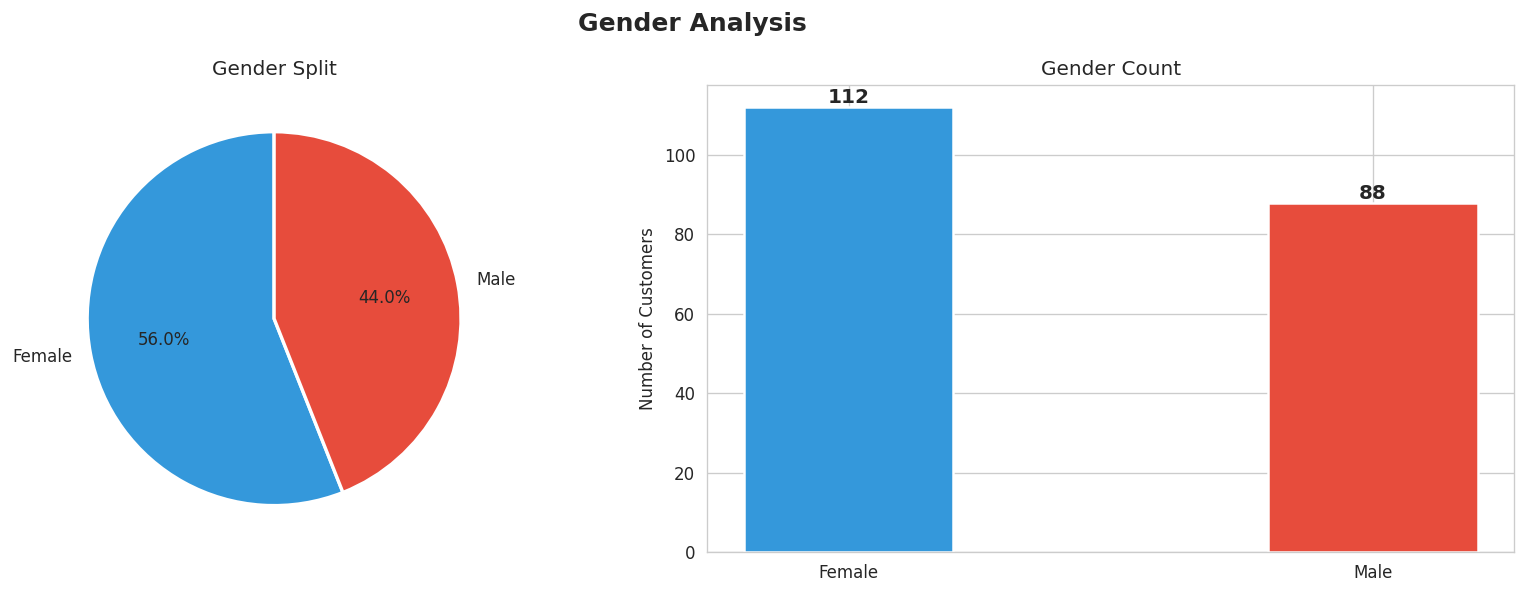

Gender distribution plotted!


In [39]:
print("GENDER DISTRIBUTION")
print("\n")
gender_counts = df['Genre'].value_counts()
print(gender_counts)
print(f"\n  Male   : {(df['Genre']=='Male').sum()} customers ({(df['Genre']=='Male').sum()/len(df)*100:.1f}%)")
print(f"  Female : {(df['Genre']=='Female').sum()} customers ({(df['Genre']=='Female').sum()/len(df)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Gender Analysis', fontsize=15, fontweight='bold')

axes[0].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
            colors=['#3498db','#e74c3c'], startangle=90,
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('Gender Split')

axes[1].bar(gender_counts.index, gender_counts.values,
            color=['#3498db','#e74c3c'], edgecolor='white', linewidth=1.5, width=0.4)
axes[1].set_title('Gender Count')
axes[1].set_ylabel('Number of Customers')
for i, v in enumerate(gender_counts.values):
    axes[1].text(i, v+1, str(v), ha='center', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()
print("Gender distribution plotted!")

# ***Histograms.***

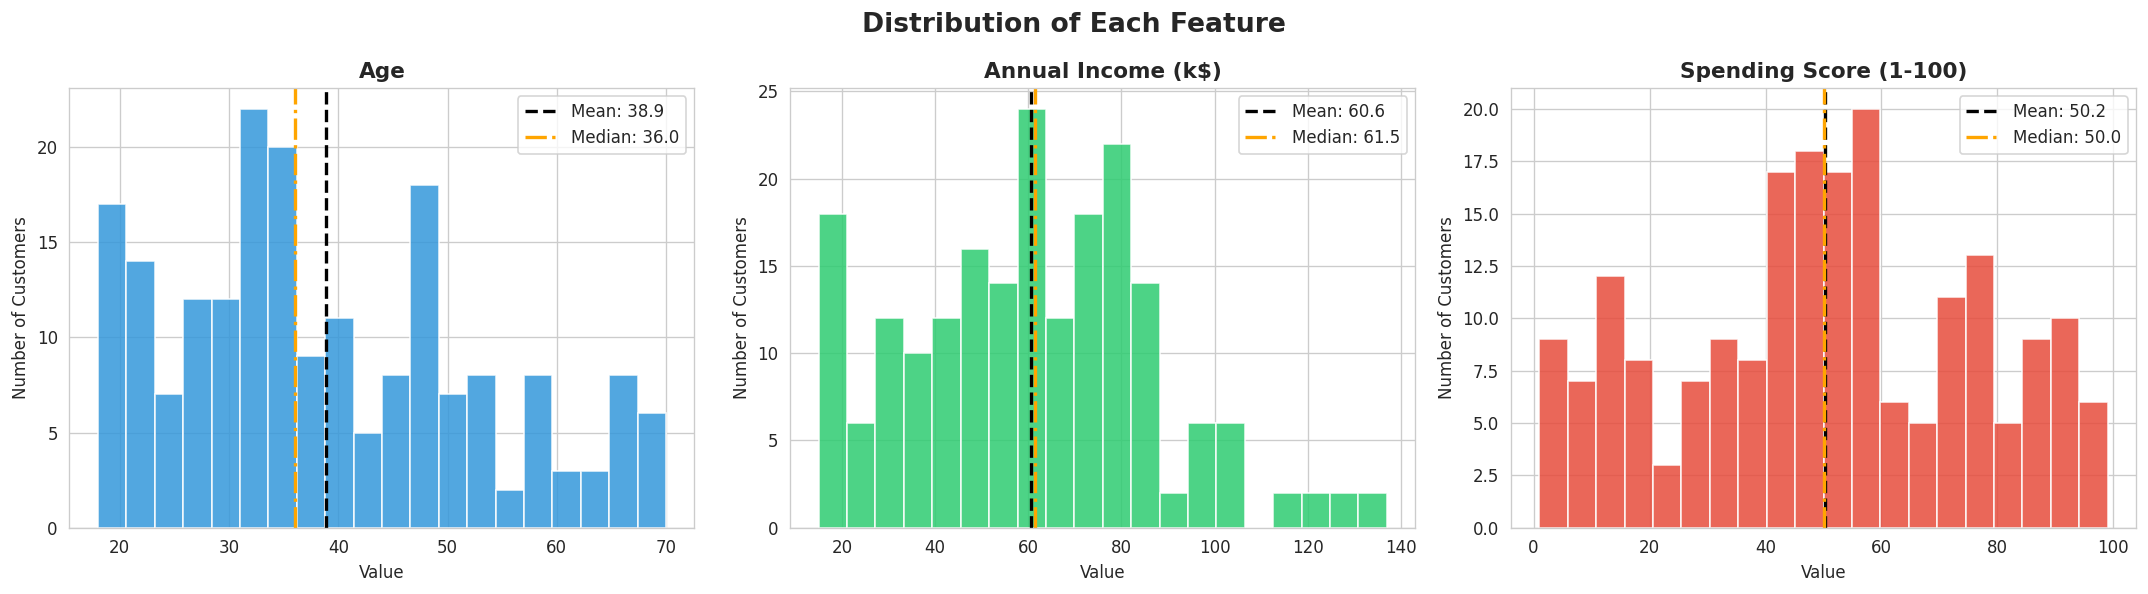

Histograms plotted!


In [40]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribution of Each Feature', fontsize=16, fontweight='bold')

colors = ['#3498db', '#2ecc71', '#e74c3c']

for i, (col, color) in enumerate(zip(cols, colors)):
    axes[i].hist(df[col], bins=20, color=color, edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Number of Customers')
    axes[i].axvline(df[col].mean(), color='black', linestyle='--',
                    linewidth=2, label=f'Mean: {df[col].mean():.1f}')
    axes[i].axvline(df[col].median(), color='orange', linestyle='-.',
                    linewidth=2, label=f'Median: {df[col].median():.1f}')
    axes[i].legend()

plt.tight_layout()
plt.show()
print("Histograms plotted!")

# **Boxplots.**

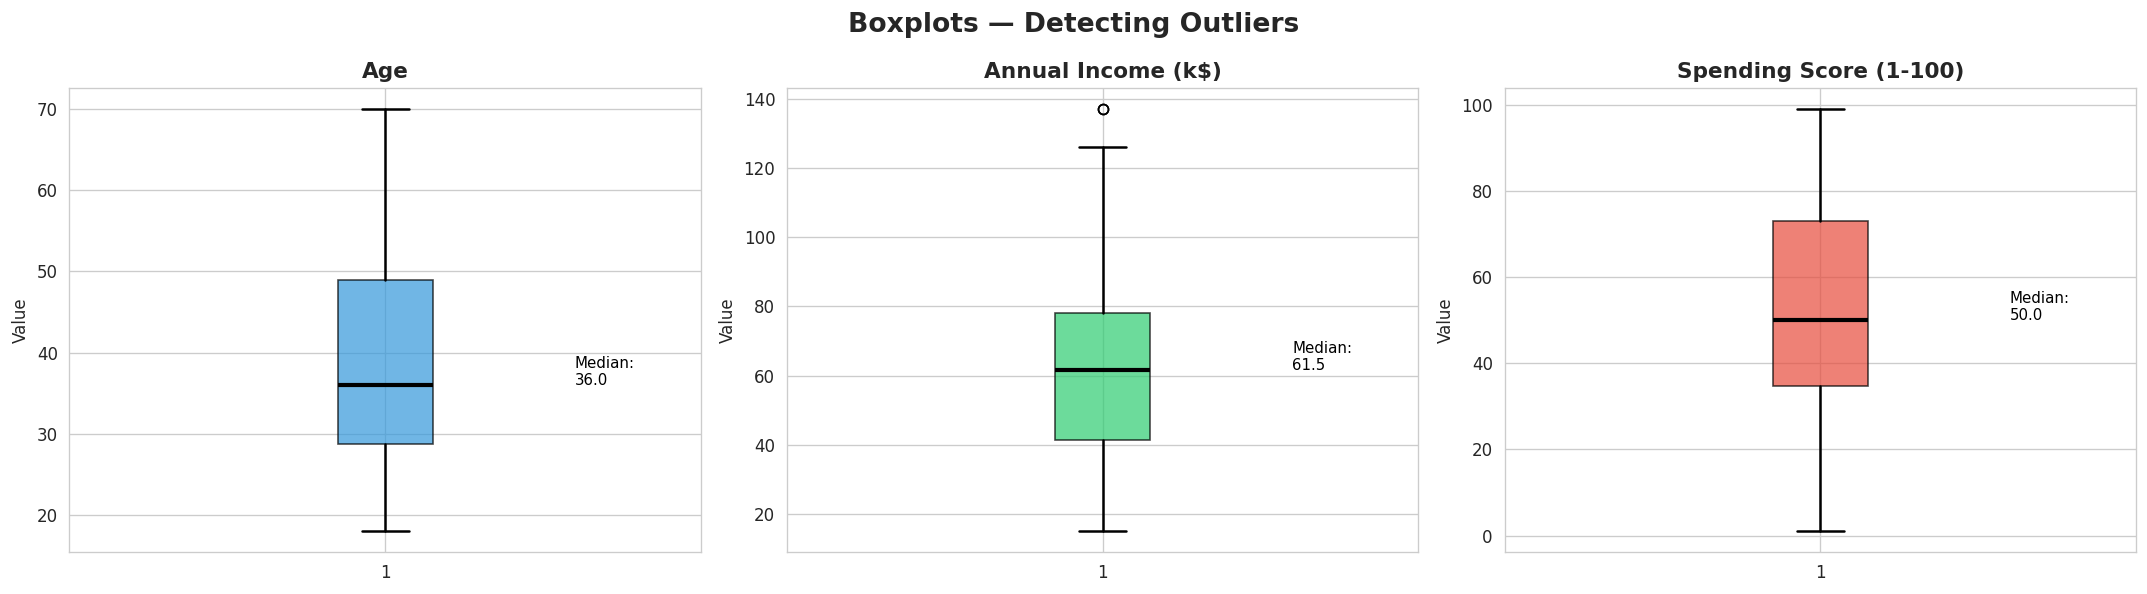

Boxplots plotted!


In [41]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Boxplots — Detecting Outliers', fontsize=16, fontweight='bold')

for i, (col, color) in enumerate(zip(cols, colors)):
    bp = axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor=color, alpha=0.7),
                    medianprops=dict(color='black', linewidth=2.5),
                    whiskerprops=dict(linewidth=1.5),
                    capprops=dict(linewidth=1.5))
    axes[i].set_title(f'{col}', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Value')
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    axes[i].text(1.3, df[col].median(), f'Median:\n{df[col].median():.1f}',
                 fontsize=9, color='black')

plt.tight_layout()
plt.show()
print("Boxplots plotted!")

# **Gender vs Features.**

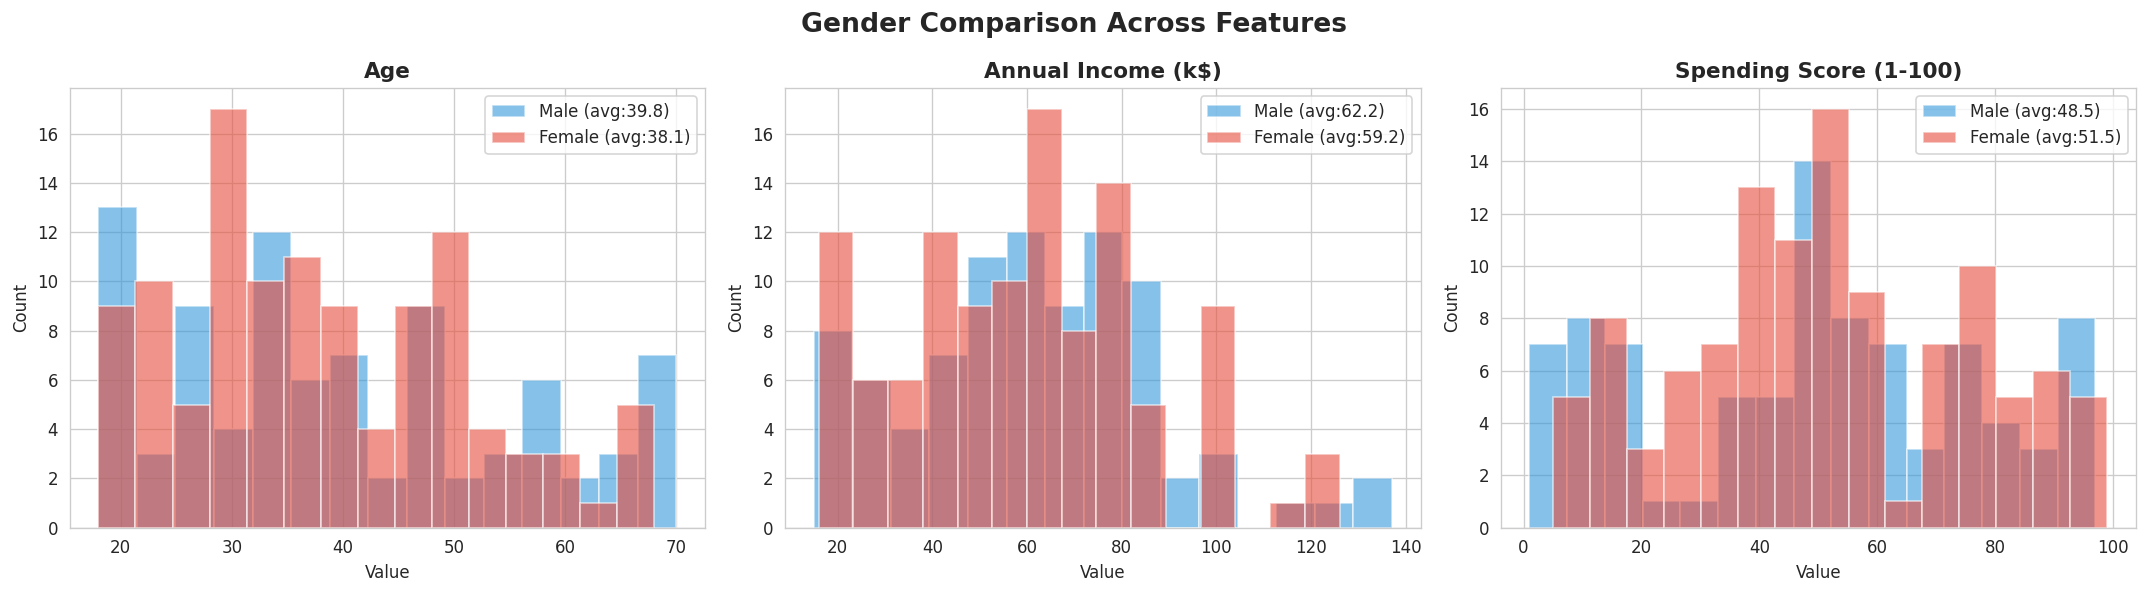

Gender comparison plotted!


In [42]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Gender Comparison Across Features', fontsize=16, fontweight='bold')

for i, col in enumerate(cols):
    male_data   = df[df['Genre']=='Male'][col]
    female_data = df[df['Genre']=='Female'][col]
    axes[i].hist(male_data,   bins=15, alpha=0.6, color='#3498db', label=f'Male (avg:{male_data.mean():.1f})',   edgecolor='white')
    axes[i].hist(female_data, bins=15, alpha=0.6, color='#e74c3c', label=f'Female (avg:{female_data.mean():.1f})', edgecolor='white')
    axes[i].set_title(col, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.tight_layout()
plt.show()
print("Gender comparison plotted!")

# **Correlation Heatmap.**

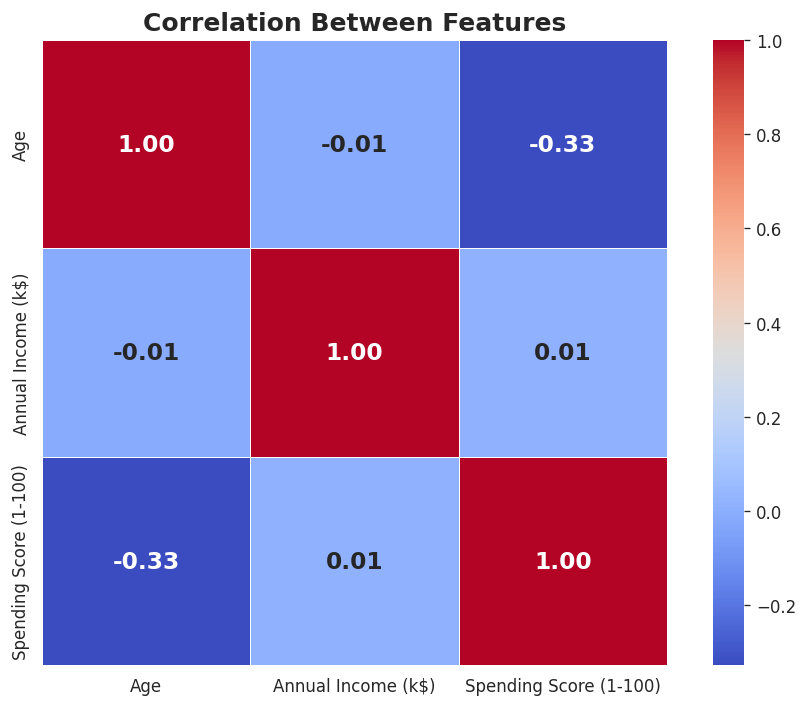


Interpretation:
  Age vs Income       : -0.01 → nearly no relationship
  Age vs Spending     : -0.33 → slight negative (older = less spending)
  Income vs Spending  : 0.01 → nearly no relationship


In [43]:
plt.figure(figsize=(8, 6))
numeric_df = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
corr = numeric_df.corr()

sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm',
            linewidths=0.5, square=True,
            annot_kws={"size": 14, "weight": "bold"})

plt.title('Correlation Between Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print(f"  Age vs Income       : {corr.loc['Age','Annual Income (k$)']:.2f} → nearly no relationship")
print(f"  Age vs Spending     : {corr.loc['Age','Spending Score (1-100)']:.2f} → slight negative (older = less spending)")
print(f"  Income vs Spending  : {corr.loc['Annual Income (k$)','Spending Score (1-100)']:.2f} → nearly no relationship")

# **Pairplot.**

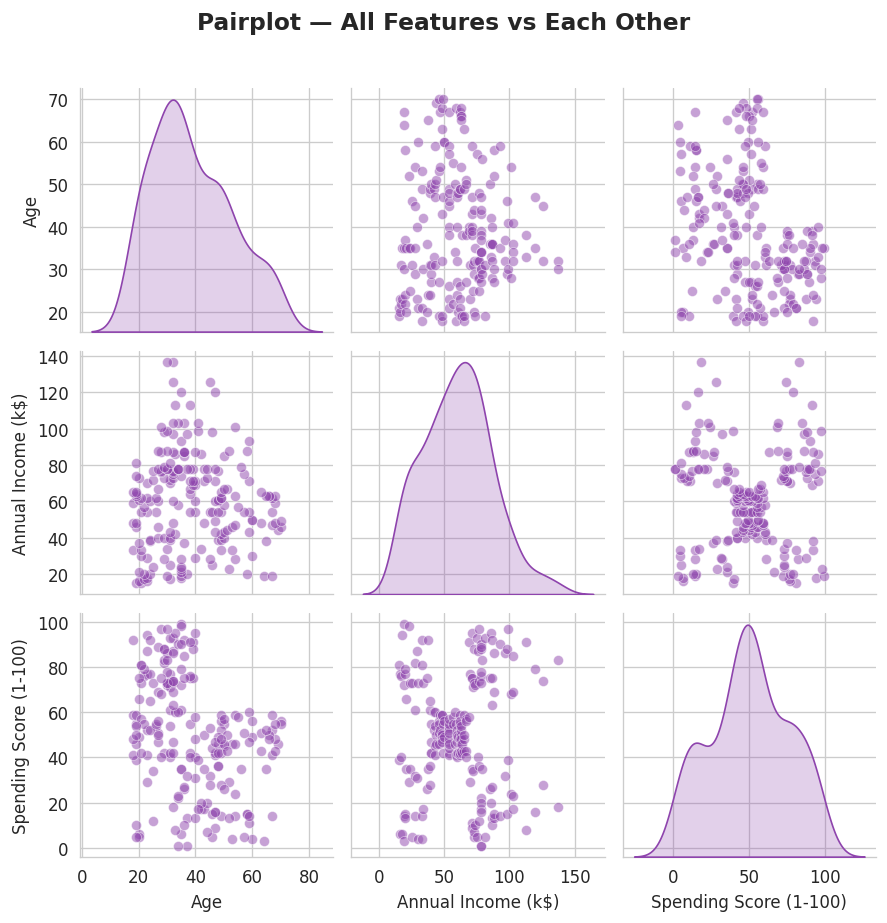

Pairplot done! Look at Income vs Spending — you can already see 5 natural groups!


In [44]:
sns.pairplot(df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']],
             diag_kind='kde',
             plot_kws={'alpha': 0.5, 'color': '#8e44ad'},
             diag_kws={'color': '#8e44ad', 'fill': True})

plt.suptitle('Pairplot — All Features vs Each Other',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print("Pairplot done! Look at Income vs Spending — you can already see 5 natural groups!")

# **Scatter Plots.**

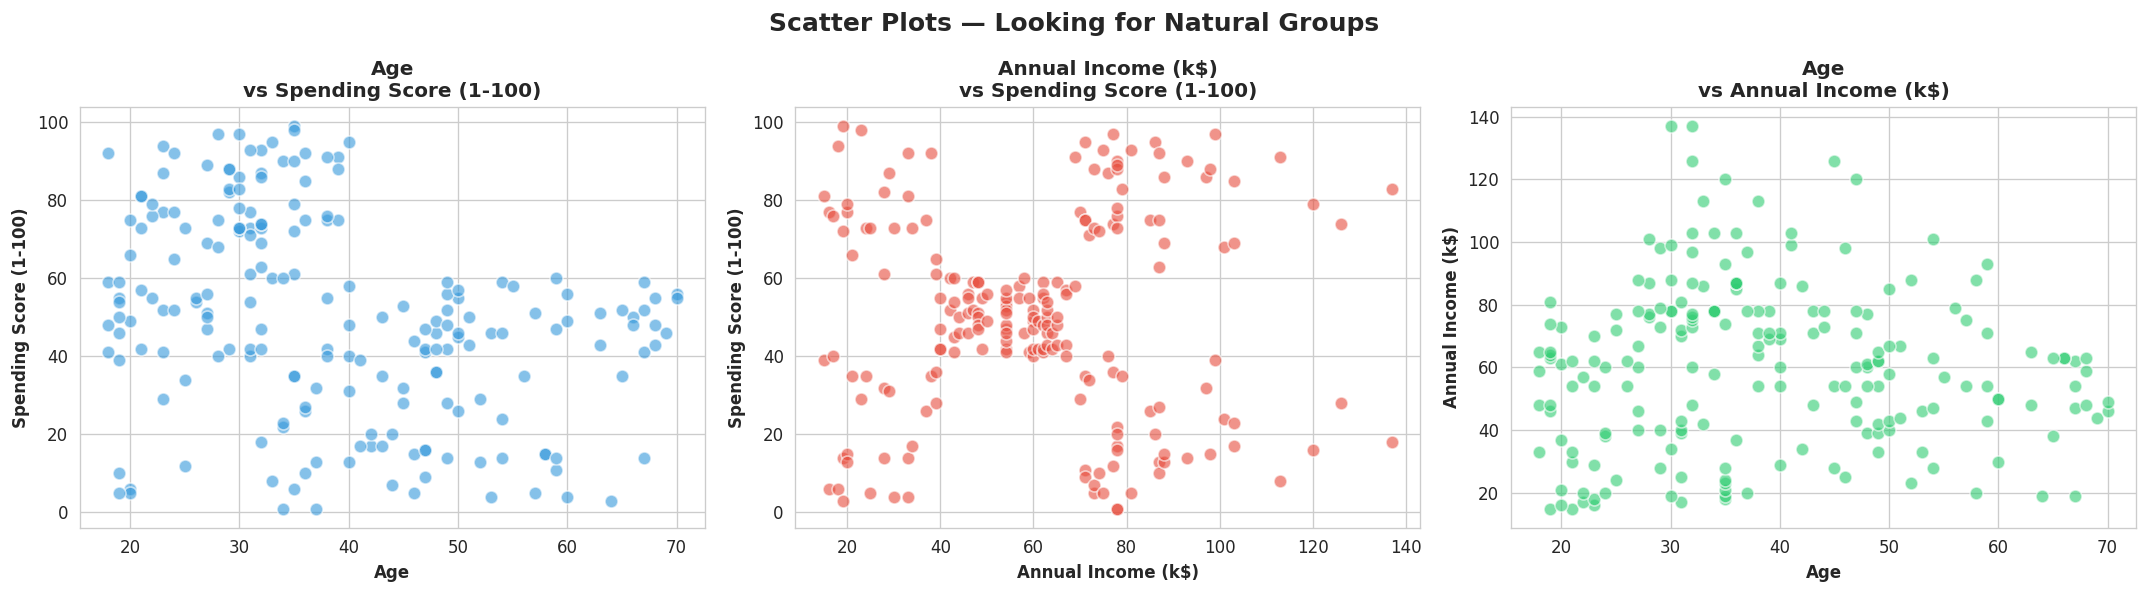

Scatter plots done!
Look at 'Annual Income vs Spending Score' — 5 clear groups are visible!


In [45]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Scatter Plots — Looking for Natural Groups', fontsize=15, fontweight='bold')

pairs = [
    ('Age', 'Spending Score (1-100)'),
    ('Annual Income (k$)', 'Spending Score (1-100)'),
    ('Age', 'Annual Income (k$)')
]

scatter_colors = ['#3498db', '#e74c3c', '#2ecc71']

for i, ((x, y), color) in enumerate(zip(pairs, scatter_colors)):
    axes[i].scatter(df[x], df[y], color=color, alpha=0.6, edgecolors='white', s=60)
    axes[i].set_xlabel(x, fontweight='bold')
    axes[i].set_ylabel(y, fontweight='bold')
    axes[i].set_title(f'{x}\nvs {y}', fontweight='bold')

plt.tight_layout()
plt.show()
print("Scatter plots done!")
print("Look at 'Annual Income vs Spending Score' — 5 clear groups are visible!")

# ***Data Preprocessing & Scaling.***

# **Select Features & Scale.{We use only Income and Spending Score (best for clustering as seen in scatter plot)}.**

In [46]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

print("Features selected for clustering:")
print("   • Annual Income (k$)")
print("   • Spending Score (1-100)")
print(f"\n  Shape of X: {X.shape}")
print(f"  {X.shape[0]} customers × {X.shape[1]} features")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nData scaled successfully!")
print("\nBefore scaling (first 5 rows):")
print(X[:5])
print("\nAfter scaling (first 5 rows):")
print(X_scaled[:5].round(3))
print("\nAll values now have mean=0 and std=1")
print("   This ensures both features are treated equally by K-Means!")

Features selected for clustering:
   • Annual Income (k$)
   • Spending Score (1-100)

  Shape of X: (200, 2)
  200 customers × 2 features

Data scaled successfully!

Before scaling (first 5 rows):
[[15 39]
 [15 81]
 [16  6]
 [16 77]
 [17 40]]

After scaling (first 5 rows):
[[-1.739 -0.435]
 [-1.739  1.196]
 [-1.701 -1.716]
 [-1.701  1.04 ]
 [-1.663 -0.396]]

All values now have mean=0 and std=1
   This ensures both features are treated equally by K-Means!


# ***Finding Optimal K — Elbow Method.***

# **Elbow Method.**

In [47]:
wcss = []
k_range = range(1, 11)

print("Fitting K-Means for K = 1 to 10...")
print("\n")

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, init='k-means++',
                         max_iter=300, n_init=10, random_state=42)
    kmeans_temp.fit(X_scaled)
    wcss.append(kmeans_temp.inertia_)
    print(f"  K = {k:2d}  →  WCSS = {kmeans_temp.inertia_:.2f}")

print("\nElbow method complete!")

Fitting K-Means for K = 1 to 10...


  K =  1  →  WCSS = 400.00
  K =  2  →  WCSS = 269.69
  K =  3  →  WCSS = 157.70
  K =  4  →  WCSS = 108.92
  K =  5  →  WCSS = 65.57
  K =  6  →  WCSS = 55.06
  K =  7  →  WCSS = 44.86
  K =  8  →  WCSS = 37.23
  K =  9  →  WCSS = 32.39
  K = 10  →  WCSS = 29.98

Elbow method complete!


# **Plot Elbow Curve.**

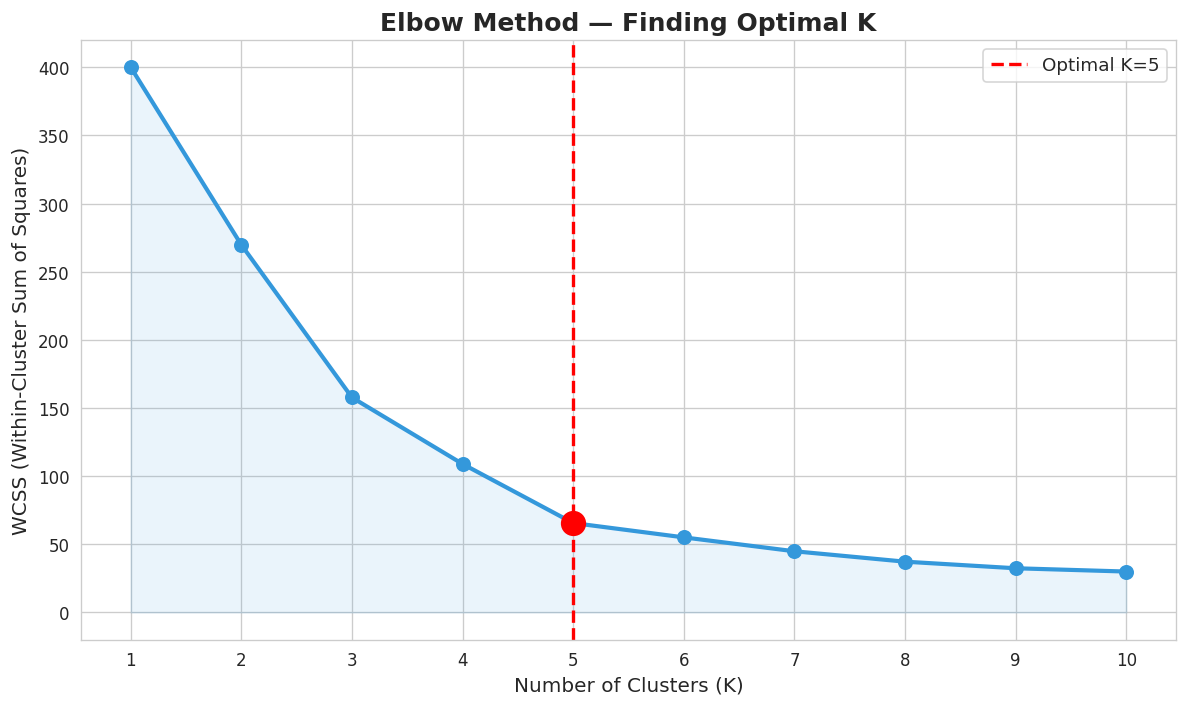

Elbow curve plotted!
The 'elbow' bends sharply at K=5
   → After K=5, adding more clusters gives very little improvement
   → Therefore, OPTIMAL K = 5


In [48]:
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, 'bo-', linewidth=2.5, markersize=8, color='#3498db')
plt.fill_between(k_range, wcss, alpha=0.1, color='#3498db')

plt.axvline(x=5, color='red', linestyle='--', linewidth=2, label='Optimal K=5')
plt.scatter([5], [wcss[4]], color='red', s=200, zorder=5)

plt.title('Elbow Method — Finding Optimal K', fontsize=15, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(k_range)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print("Elbow curve plotted!")
print("The 'elbow' bends sharply at K=5")
print("   → After K=5, adding more clusters gives very little improvement")
print("   → Therefore, OPTIMAL K = 5")

# ***Model Training — K-Means with K=5.***
# **Train Model.**

In [49]:
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k,
                init='k-means++',
                max_iter=300,
                n_init=10,
                random_state=42)

kmeans.fit(X_scaled)

df['Cluster'] = kmeans.labels_

print("K-Means model trained successfully!")
print(f"\nNumber of clusters : {optimal_k}")
print(f"Final WCSS (Inertia): {kmeans.inertia_:.4f}")
print(f"\nCustomers per cluster:")
print("\n")
for i in range(optimal_k):
    count = (df['Cluster'] == i).sum()
    print(f"  Cluster {i} : {count} customers")

print(f"\nCluster Centroids (scaled):")
print(pd.DataFrame(kmeans.cluster_centers_,
                   columns=['Income (scaled)', 'Spending (scaled)']))

K-Means model trained successfully!

Number of clusters : 5
Final WCSS (Inertia): 65.5684

Customers per cluster:


  Cluster 0 : 81 customers
  Cluster 1 : 39 customers
  Cluster 2 : 22 customers
  Cluster 3 : 35 customers
  Cluster 4 : 23 customers

Cluster Centroids (scaled):
   Income (scaled)  Spending (scaled)
0        -0.200913          -0.026456
1         0.991583           1.239503
2        -1.329545           1.132178
3         1.055003          -1.284439
4        -1.307519          -1.136965


# ***Cluster Scatter Plot.***

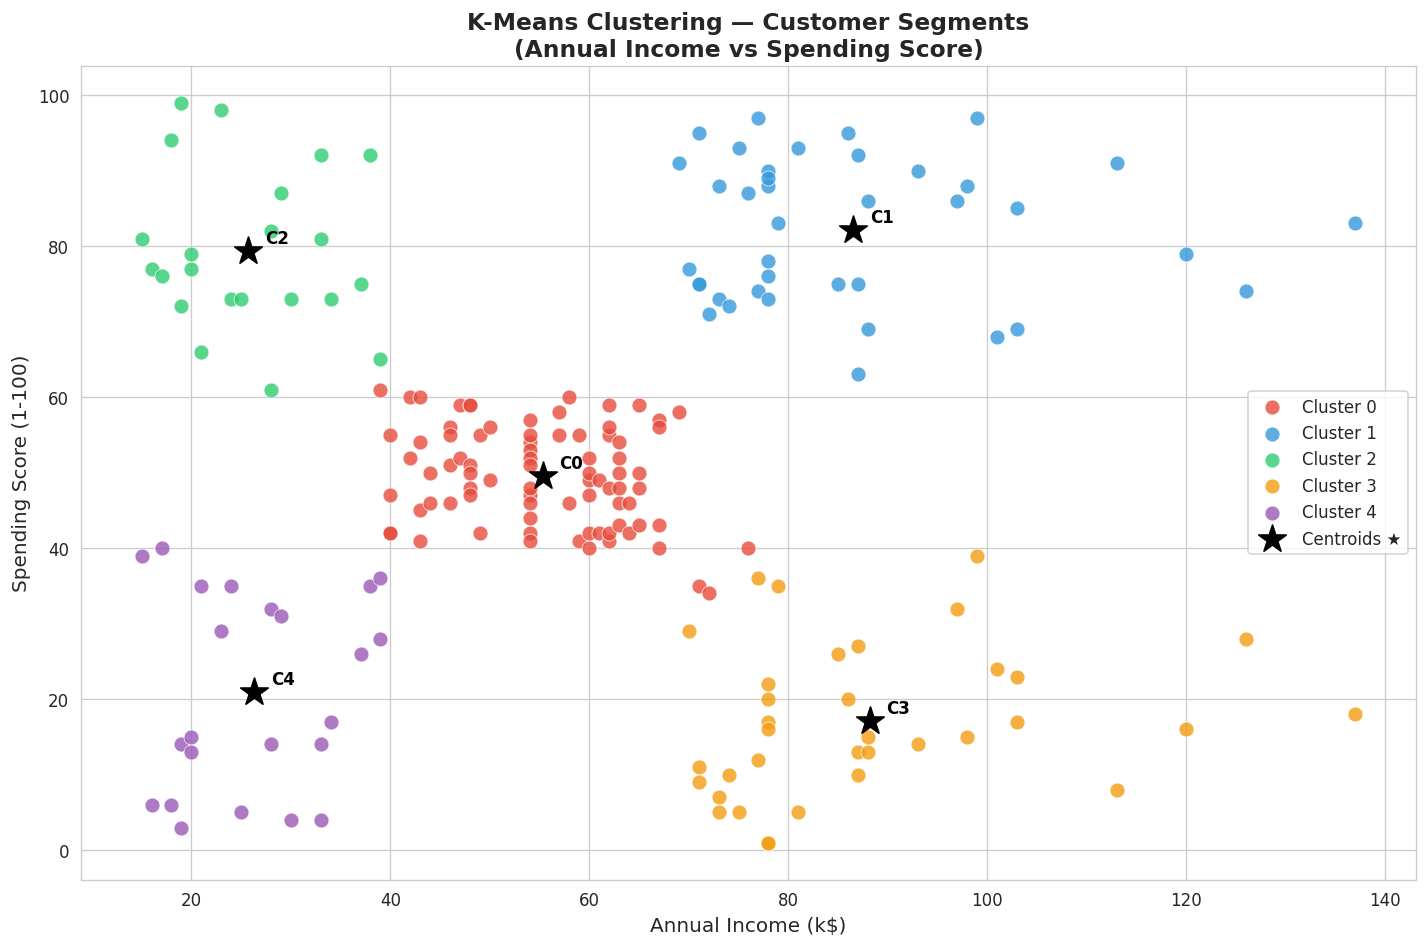

Cluster scatter plot with centroids plotted!


In [50]:
plt.figure(figsize=(12, 8))

cluster_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']
cluster_labels = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4']

for i in range(optimal_k):
    mask = df['Cluster'] == i
    plt.scatter(df.loc[mask, 'Annual Income (k$)'],
                df.loc[mask, 'Spending Score (1-100)'],
                c=cluster_colors[i], label=cluster_labels[i],
                s=80, alpha=0.8, edgecolors='white', linewidth=0.5)

centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            s=300, c='black', marker='*', zorder=10, label='Centroids ★')

for i, (x, y) in enumerate(centroids_original):
    plt.annotate(f'C{i}', (x, y), textcoords="offset points",
                 xytext=(10, 5), fontsize=10, fontweight='bold', color='black')

plt.title('K-Means Clustering — Customer Segments\n(Annual Income vs Spending Score)',
          fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()
print("Cluster scatter plot with centroids plotted!")

# **Cluster Profiles.**

In [51]:
print("CLUSTER PROFILE SUMMARY")
print("\n")

profile = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
print(profile)

print("\n" + "*"*60)
print("CLUSTER INTERPRETATIONS")
print("*"*60)

interpretations = {
    0: "High Income, LOW Spending  → Careful/Saving customers",
    1: "Low Income, LOW Spending  → Budget-conscious customers",
    2: "Medium Income, Medium Spending → Average/Regular customers",
    3: "High Income, HIGH Spending → Premium/VIP customers",
    4: "Low Income, HIGH Spending  → Impulsive spenders"
}

for cluster_id, desc in interpretations.items():
    count = (df['Cluster'] == cluster_id).sum()
    print(f"\n  Cluster {cluster_id} ({count} customers):")
    print(f"  {desc}")

CLUSTER PROFILE SUMMARY


          Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                  
0        42.7                55.3                    49.5
1        32.7                86.5                    82.1
2        25.3                25.7                    79.4
3        41.1                88.2                    17.1
4        45.2                26.3                    20.9

************************************************************
CLUSTER INTERPRETATIONS
************************************************************

  Cluster 0 (81 customers):
  High Income, LOW Spending  → Careful/Saving customers

  Cluster 1 (39 customers):
  Low Income, LOW Spending  → Budget-conscious customers

  Cluster 2 (22 customers):
  Medium Income, Medium Spending → Average/Regular customers

  Cluster 3 (35 customers):
  High Income, HIGH Spending → Premium/VIP customers

  Cluster 4 (23 customers):
  Low Income, HIGH Spending  → Impulsive spenders

# ***Save Model.***

In [52]:
import joblib

model_path  = "220143_DT_-_K_Means_Clustering/model/220143.pkl"
scaler_path = "220143_DT_-_K_Means_Clustering/model/220143_scaler.pkl"

joblib.dump(kmeans, model_path)
joblib.dump(scaler, scaler_path)

print("Model saved!")
print("Scaler saved!")
print(f"\nModel  → {model_path}")
print(f"Scaler → {scaler_path}")

import os
print(f"\nModel file size  : {os.path.getsize(model_path)} bytes")
print(f"Scaler file size : {os.path.getsize(scaler_path)} bytes")

Model saved!
Scaler saved!

Model  → 220143_DT_-_K_Means_Clustering/model/220143.pkl
Scaler → 220143_DT_-_K_Means_Clustering/model/220143_scaler.pkl

Model file size  : 1607 bytes
Scaler file size : 663 bytes


# ***Real-World Prediction — Custom 10 Customers.***
# **Load & Predict Custom Data.**

In [53]:
custom_path = "220143_DT_-_K_Means_Clustering/dataset/custom_customers.csv"
df_custom = pd.read_csv(custom_path)

print("Custom data loaded from GitHub repo!")
print(f"Shape: {df_custom.shape}")
print("\nYour 10 custom customers:")
print(df_custom)

X_custom = df_custom[['Annual Income (k$)', 'Spending Score (1-100)']].values

X_custom_scaled = scaler.transform(X_custom)

loaded_model = joblib.load(model_path)
predictions = loaded_model.predict(X_custom_scaled)

df_custom['Assigned Cluster'] = predictions

print("\n" + "*"*60)
print("CLUSTER PREDICTIONS FOR YOUR 10 CUSTOM CUSTOMERS")
print("*"*60)
print(df_custom.to_string(index=False))

Custom data loaded from GitHub repo!
Shape: (10, 4)

Your 10 custom customers:
   CustomerID  Age  Annual Income (k$)  Spending Score (1-100)
0           1   22                  18                      82
1           2   35                  62                      45
2           3   28                  45                      71
3           4   52                 110                      28
4           5   47                  95                      15
5           6   31                  55                      60
6           7   24                  20                      90
7           8   41                  78                      38
8           9   19                  14                      77
9          10   60                 120                      20

************************************************************
CLUSTER PREDICTIONS FOR YOUR 10 CUSTOM CUSTOMERS
************************************************************
 CustomerID  Age  Annual Income (k$)  Spending Score (1-

# **Custom Prediction Table.**

In [54]:
cluster_names = {
    0: "High Income, Low Spender",
    1: "Low Income, Low Spender",
    2: "Average Customer",
    3: "High Income, High Spender",
    4: "Low Income, High Spender"
}

df_custom['Cluster Profile'] = df_custom['Assigned Cluster'].map(cluster_names)

print("FINAL PREDICTION RESULTS — YOUR 10 CUSTOM CUSTOMERS")
print("\n")
print(df_custom[['CustomerID', 'Age', 'Annual Income (k$)',
                  'Spending Score (1-100)', 'Assigned Cluster', 'Cluster Profile']].to_string(index=False))
print("\n")
print("All 10 customers successfully assigned to clusters!")

FINAL PREDICTION RESULTS — YOUR 10 CUSTOM CUSTOMERS


 CustomerID  Age  Annual Income (k$)  Spending Score (1-100)  Assigned Cluster           Cluster Profile
          1   22                  18                      82                 2          Average Customer
          2   35                  62                      45                 0  High Income, Low Spender
          3   28                  45                      71                 2          Average Customer
          4   52                 110                      28                 3 High Income, High Spender
          5   47                  95                      15                 3 High Income, High Spender
          6   31                  55                      60                 0  High Income, Low Spender
          7   24                  20                      90                 2          Average Customer
          8   41                  78                      38                 3 High Income, High Spender
 

# **Plot Custom Customers on Cluster Map.**

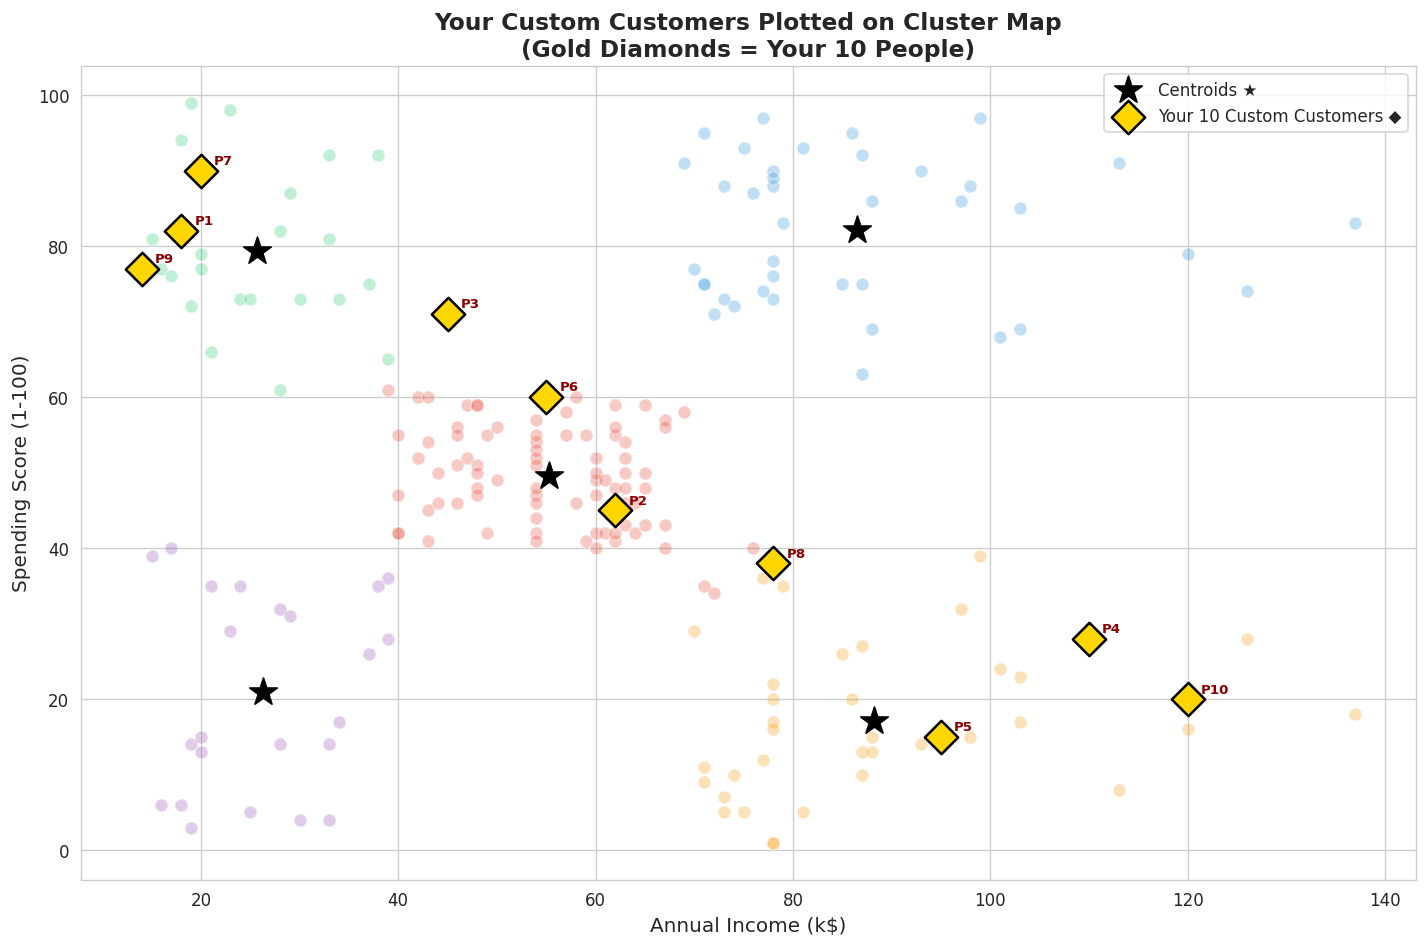

Custom customers plotted on cluster map!


In [55]:
plt.figure(figsize=(12, 8))

for i in range(optimal_k):
    mask = df['Cluster'] == i
    plt.scatter(df.loc[mask, 'Annual Income (k$)'],
                df.loc[mask, 'Spending Score (1-100)'],
                c=cluster_colors[i], s=60, alpha=0.3, edgecolors='white')

plt.scatter(centroids_original[:, 0], centroids_original[:, 1],
            s=300, c='black', marker='*', zorder=10, label='Centroids ★')

plt.scatter(df_custom['Annual Income (k$)'],
            df_custom['Spending Score (1-100)'],
            c='gold', s=200, marker='D', edgecolors='black',
            linewidth=1.5, zorder=11, label='Your 10 Custom Customers ◆')

for _, row in df_custom.iterrows():
    plt.annotate(f"P{int(row['CustomerID'])}",
                 (row['Annual Income (k$)'], row['Spending Score (1-100)']),
                 textcoords="offset points", xytext=(8, 4),
                 fontsize=8, fontweight='bold', color='darkred')

plt.title('Your Custom Customers Plotted on Cluster Map\n(Gold Diamonds = Your 10 People)',
          fontsize=14, fontweight='bold')
plt.xlabel('Annual Income (k$)', fontsize=12)
plt.ylabel('Spending Score (1-100)', fontsize=12)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()
print("Custom customers plotted on cluster map!")

##Cluster Interpretation

**Cluster 0 — High Income, Low Spending:** These customers earn well but spend conservatively. They are likely saving-oriented individuals who prioritize financial security over luxury purchases.

**Cluster 1 — Low Income, Low Spending:** These are budget-conscious customers with limited purchasing power. They spend carefully due to financial constraints and are unlikely to respond to premium marketing.

**Cluster 2 — Average Customers:** Middle-income, moderate spenders who represent the general customer base. They are the most stable segment and respond well to loyalty programs and discounts.

**Cluster 3 — High Income, High Spending (VIP):** The most valuable segment — wealthy customers who spend freely. These are prime targets for premium products, exclusive offers, and VIP membership programs.

**Cluster 4 — Low Income, High Spending (Impulsive):** Despite lower incomes, these customers spend heavily — likely driven by lifestyle aspirations or impulsive buying behavior. They respond well to promotions and flash sales.

# **Final Summary.**

In [56]:
print("FINAL SUMMARY")
print("\n")
print(f"  Standard dataset     : Mall Customers (200 rows)")
print(f"  Algorithm            : K-Means Clustering")
print(f"  Optimal K            : 5 (from Elbow Method)")
print(f"  Model saved          : model/220143.pkl")
print(f"  Scaler saved         : model/220143_scaler.pkl")
print(f"  Custom data          : 10 real-world customers predicted")
print(f"  GitHub repo          : https://github.com/rubyat43/220143_DT_-_K_Means_Clustering")
print("\n")

FINAL SUMMARY


  Standard dataset     : Mall Customers (200 rows)
  Algorithm            : K-Means Clustering
  Optimal K            : 5 (from Elbow Method)
  Model saved          : model/220143.pkl
  Scaler saved         : model/220143_scaler.pkl
  Custom data          : 10 real-world customers predicted
  GitHub repo          : https://github.com/rubyat43/220143_DT_-_K_Means_Clustering




In [60]:
from google.colab import files

files.download('220143_DT_-_K_Means_Clustering/model/220143.pkl')
files.download('220143_DT_-_K_Means_Clustering/model/220143_scaler.pkl')

print("Check your computer's Downloads folder!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Check your computer's Downloads folder!
